# Mortalidade prematura por doenças crônicas — o indicador 3.4 da ONU

**A pergunta:** de cada 100 pessoas que chegam aos 30 anos, quantas morrem
antes dos 70 por doença do coração, câncer, diabetes ou doença respiratória
crônica? Essa é a **meta 3.4 dos Objetivos de Desenvolvimento Sustentável**, que
o Brasil se comprometeu a reduzir em um terço até 2030. Ela é calculável a
partir do SIM — e este notebook calcula, do arquivo bruto ao número final.

**Fonte:** Sistema de Informações sobre Mortalidade (SIM/DATASUS), com
denominadores do IBGE.

**Tempo estimado:** 6 a 10 minutos (baixa vários anos).

**O que você leva daqui:** uma função que classifica qualquer código da CID-10
em capítulo, o cálculo completo da probabilidade de morte prematura, a série
histórica e o gradiente social da mortalidade por escolaridade.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


In [4]:
# ---- Uma armadilha do catálogo, e como escapar dela --------------------
# O parâmetro state= diz onde PROCURAR, e não filtra: a PySUS devolve o arquivo
# NACIONAL ao lado do arquivo do estado. Pior, para 2025 e 2026 ela devolve
# SÓ o nacional. Pegar o primeiro da lista entrega o Brasil inteiro rotulado
# como estado — era o que este notebook fazia, e a mortalidade saía três vezes
# menor do que é.
import os

from pysus import list_files


def arquivo_da_uf(arquivos, uf, prefixo):
    """Entre os arquivos devolvidos, o DO ESTADO. Falha alto se não houver."""
    do_estado = [str(a) for a in arquivos
                 if os.path.basename(str(a)).upper().startswith(
                     f"{prefixo}{uf}".upper())]
    if not do_estado:
        nacionais = [os.path.basename(str(a)) for a in arquivos]
        raise ValueError(
            f"Não existe arquivo de {uf} para este ano: a PySUS ofereceu só "
            f"{nacionais}, que é nacional. Use ano_com_arquivo_da_uf() para "
            "escolher um ano que tenha arquivo estadual.")
    return do_estado[0].replace("\\", "/")


def ano_com_arquivo_da_uf(base, uf, prefixo, ate=None):
    """O ano mais recente COM arquivo do estado — que é também um ano fechado.

    Anos em andamento (2025, 2026) só têm o arquivo nacional, e ainda por cima
    estão incompletos: contar óbitos neles subestima tudo.
    """
    catalogo = list_files(dataset=base, state=uf)
    anos = []
    for nome, ano in zip(catalogo["name"], catalogo["year"]):
        if ano != ano:            # NaN
            continue
        if os.path.basename(str(nome)).upper().startswith(f"{prefixo}{uf}".upper()):
            if ate is None or int(ano) <= int(ate):
                anos.append(int(ano))
    if not anos:
        raise ValueError(f"Nenhum ano de {base} tem arquivo de {uf}.")
    return max(anos)

## 1. O que você pode trocar

In [5]:
UF = "PR"          # estado analisado
ANOS_SERIE = 9     # quantos anos de série histórica

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}
CODIGO_UF = {sigla: codigo for codigo, sigla in UFS.items()}
print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. Quais anos existem de verdade

Nunca chute o último ano disponível. O SIM leva cerca de dois anos para fechar
um ano de dados, e pedir um ano inexistente devolve uma tabela vazia **sem
mensagem de erro** — um dos enganos mais comuns de quem começa.

In [6]:
from pysus import list_files

catalogo = list_files(dataset="sim", state=UF)
anos = sorted(int(a) for a in catalogo["year"].dropna().unique())

ANO = anos[-1]
ANO_INICIAL = max(anos[0], ANO - ANOS_SERIE + 1)
serie = [a for a in anos if ANO_INICIAL <= a <= ANO]

print(f"Anos disponíveis para {UF}: de {anos[0]} a {anos[-1]} ({len(anos)} anos)")
print(f"Ano de referência: {ANO}")
print(f"Série histórica: {serie[0]} a {serie[-1]}")

Anos disponíveis para PR: de 1979 a 2026 (48 anos)
Ano de referência: 2026
Série histórica: 2018 a 2026


In [7]:
from pysus import sim

def arquivos_sim(uf, anos):
    "Baixa os arquivos e devolve os caminhos prontos para o SQL."
    if isinstance(anos, int):
        anos = [anos]
    caminhos = sim(uf, anos)
    return [c.replace("\\", "/") for c in caminhos]

ANO = ano_com_arquivo_da_uf("sim", UF, "DO", ate=ANO)
print(f"Ano usado: {ANO} (o mais recente com arquivo do estado)")
arquivo_ano = arquivo_da_uf(sim(UF, ANO), UF, "DO")

total = con.execute(f"SELECT count(*) FROM read_parquet('{arquivo_ano}')").fetchone()[0]
colunas = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{arquivo_ano}')").df()

print(f"{UF} em {ANO}: {mil(total)} óbitos registrados")
print(f"A declaração de óbito tem {len(colunas)} campos.")
print()
print("Os que este notebook usa:")
for nome, papel in [
    ("CAUSABAS", "causa básica do óbito, em código CID-10"),
    ("IDADE", "idade codificada (a unidade vem no primeiro dígito)"),
    ("SEXO", "1 masculino, 2 feminino"),
    ("ESC2010", "escolaridade, 0 a 5"),
    ("RACACOR", "raça/cor, 1 a 5"),
    ("DTOBITO", "data do óbito, no formato ddmmaaaa"),
    ("CODMUNRES", "município de residência"),
]:
    print(f"  {nome:<10} {papel}")

Ano usado: 2024 (o mais recente com arquivo do estado)


PR em 2024: 89.122 óbitos registrados
A declaração de óbito tem 87 campos.
Os que este notebook usa:
  CAUSABAS   causa básica do óbito, em código CID-10
  IDADE      idade codificada (a unidade vem no primeiro dígito)
  SEXO       1 masculino, 2 feminino
  ESC2010    escolaridade, 0 a 5
  RACACOR    raça/cor, 1 a 5
  DTOBITO    data do óbito, no formato ddmmaaaa
  CODMUNRES  município de residência


## 3. Traduzindo a CID-10 em capítulos

A causa básica vem como código — `I219`, `C349`, `E149`. Sozinho, um código não
diz nada a quem lê. A CID-10 organiza todos eles em 22 capítulos, e é assim que
a mortalidade é apresentada em qualquer publicação oficial.

A função abaixo faz essa tradução e serve para qualquer base que traga CID:
SIM, SIH, SINAN.

In [8]:
CAPITULOS_CID10 = [
    ("A00-B99", "I. Infecciosas e parasitárias"),
    ("C00-D48", "II. Neoplasias (tumores)"),
    ("D50-D89", "III. Sangue e imunidade"),
    ("E00-E90", "IV. Endócrinas, nutricionais e metabólicas"),
    ("F00-F99", "V. Transtornos mentais e comportamentais"),
    ("G00-G99", "VI. Sistema nervoso"),
    ("H00-H59", "VII. Olho e anexos"),
    ("H60-H95", "VIII. Ouvido e apófise mastoide"),
    ("I00-I99", "IX. Aparelho circulatório"),
    ("J00-J99", "X. Aparelho respiratório"),
    ("K00-K93", "XI. Aparelho digestivo"),
    ("L00-L99", "XII. Pele e tecido subcutâneo"),
    ("M00-M99", "XIII. Sistema osteomuscular"),
    ("N00-N99", "XIV. Aparelho geniturinário"),
    ("O00-O99", "XV. Gravidez, parto e puerpério"),
    ("P00-P96", "XVI. Período perinatal"),
    ("Q00-Q99", "XVII. Malformações congênitas"),
    ("R00-R99", "XVIII. Causas mal definidas"),
    ("S00-T98", "XIX. Lesões e envenenamentos"),
    ("V01-Y98", "XX. Causas externas"),
    ("Z00-Z99", "XXI. Fatores que influenciam a saúde"),
    ("U00-U99", "XXII. Códigos especiais (inclui covid-19)"),
]

def _numero(codigo):
    "Converte 'I219' no par ('I', 21)."
    texto = str(codigo).strip().upper().lstrip("*")
    if len(texto) < 3 or not texto[1:3].isdigit():
        return None, None
    return texto[0], int(texto[1:3])

def capitulo_cid10(codigo):
    "Devolve o nome do capítulo da CID-10 a que o código pertence."
    letra, numero = _numero(codigo)
    if letra is None:
        return "Não classificado"
    for faixa, nome in CAPITULOS_CID10:
        inicio, fim = faixa.split("-")
        li, ni = inicio[0], int(inicio[1:])
        lf, nf = fim[0], int(fim[1:])
        if li == lf:
            if letra == li and ni <= numero <= nf:
                return nome
        else:                                   # capítulos que cruzam letras
            if (letra == li and numero >= ni) or (letra == lf and numero <= nf) \
               or (li < letra < lf):
                return nome
    return "Não classificado"

for exemplo in ["I219", "C349", "E149", "J449", "R99", "V892", "U071"]:
    print(f"  {exemplo}  ->  {capitulo_cid10(exemplo)}")

I219  ->  IX. Aparelho circulatório
  C349  ->  II. Neoplasias (tumores)
  E149  ->  IV. Endócrinas, nutricionais e metabólicas
  J449  ->  X. Aparelho respiratório
  R99  ->  XVIII. Causas mal definidas
  V892  ->  XX. Causas externas
  U071  ->  XXII. Códigos especiais (inclui covid-19)


## 4. O retrato geral: de que morre esse estado

Antes de ir ao indicador, vale ver o quadro completo. Ele também serve de
controle de qualidade: se as causas mal definidas passarem de 10%, o registro
do estado tem problemas e todos os outros números ficam menos confiáveis.

In [9]:
obitos = con.execute(f"""
    SELECT CAUSABAS, IDADE, SEXO, ESC2010, RACACOR, DTOBITO, CODMUNRES
    FROM read_parquet('{arquivo_ano}')
""").df()

obitos["capitulo"] = obitos["CAUSABAS"].map(capitulo_cid10)

por_capitulo = (
    obitos["capitulo"].value_counts()
    .rename("Óbitos").to_frame()
    .assign(**{"% do total": lambda d: (d["Óbitos"] / d["Óbitos"].sum() * 100).round(1)})
)

mal_definidas = por_capitulo.loc["XVIII. Causas mal definidas", "% do total"] \
    if "XVIII. Causas mal definidas" in por_capitulo.index else 0.0

print(f"Qualidade do registro — causas mal definidas: {mal_definidas}%")
print("(abaixo de 10% é considerado bom; acima disso, interprete com cautela)\n")
por_capitulo.head(10)

Qualidade do registro — causas mal definidas: 1.8%
(abaixo de 10% é considerado bom; acima disso, interprete com cautela)


,Óbitos,% do total
capitulo,,
IX. Aparelho circulatório,22650,25.4
II. Neoplasias (tumores),17165,19.3
X. Aparelho respiratório,11521,12.9
XX. Causas externas,9881,11.1
"IV. Endócrinas, nutricionais e metabólicas",5280,5.9
XI. Aparelho digestivo,5176,5.8
VI. Sistema nervoso,5078,5.7
I. Infecciosas e parasitárias,3759,4.2
XIV. Aparelho geniturinário,2823,3.2


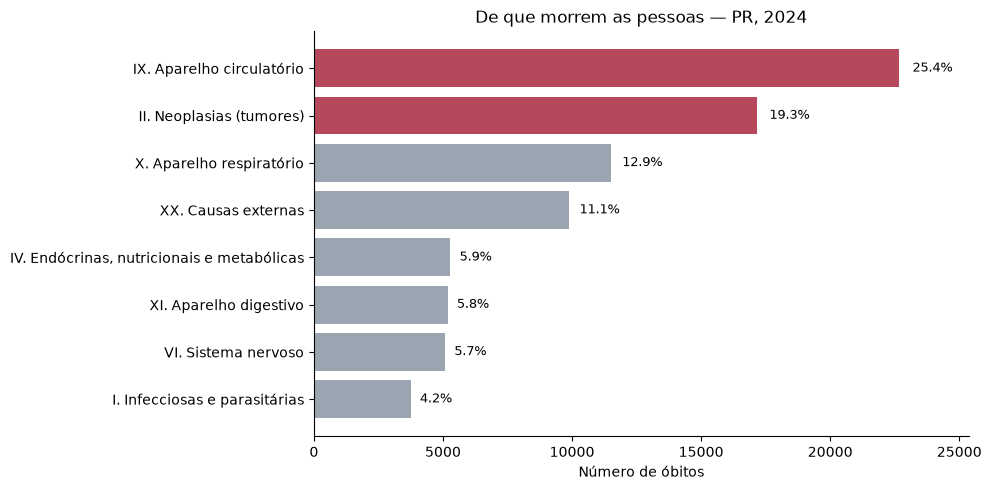

In [10]:
principais = por_capitulo.head(8).iloc[::-1]

figura, eixo = plt.subplots(figsize=(10, 5))
cores = ["#b5495b" if "circulatório" in i or "Neoplasias" in i else "#9aa5b1"
         for i in principais.index]
eixo.barh(principais.index, principais["Óbitos"], color=cores)

for indice, (nome, linha) in enumerate(principais.iterrows()):
    eixo.text(linha["Óbitos"] * 1.01, indice, f"  {linha['% do total']}%",
              va="center", fontsize=9)

eixo.set_xlabel("Número de óbitos")
eixo.set_title(f"De que morrem as pessoas — {UF}, {ANO}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
eixo.margins(x=0.12)
plt.tight_layout()
plt.show()

## 5. As quatro doenças crônicas da meta 3.4

A meta da ONU não usa capítulos inteiros: ela define **quatro grupos** de causa,
com faixas exatas da CID-10. Respeitar essas faixas é o que torna o resultado
comparável com o de qualquer outro país.

In [11]:
GRUPOS_DCNT = {
    "Doenças cardiovasculares": [("I", 0, 99)],
    "Câncer": [("C", 0, 97)],
    "Diabetes": [("E", 10, 14)],
    "Respiratórias crônicas": [("J", 30, 98)],
}

def grupo_dcnt(codigo):
    "Devolve o grupo da meta 3.4 ou None se a causa não for uma das quatro."
    letra, numero = _numero(codigo)
    if letra is None:
        return None
    for nome, faixas in GRUPOS_DCNT.items():
        for inicial, minimo, maximo in faixas:
            if letra == inicial and minimo <= numero <= maximo:
                return nome
    return None

def idade_em_anos(codigo):
    """Traduz o código de idade do SIM para anos completos.

    O primeiro dígito é a unidade: 0 a 3 são minutos, horas, dias e meses —
    ou seja, menos de um ano; 4 são anos; 5 são anos acima de cem.
    """
    texto = str(codigo).strip()
    if len(texto) < 3 or not texto[:3].isdigit():
        return None
    unidade, valor = int(texto[0]), int(texto[1:3])
    if unidade == 5:
        return 100 + valor
    if unidade == 4:
        return valor
    return 0

obitos["idade"] = obitos["IDADE"].map(idade_em_anos)
obitos["grupo_dcnt"] = obitos["CAUSABAS"].map(grupo_dcnt)

prematuros = obitos[(obitos["idade"] >= 30) & (obitos["idade"] < 70)
                    & obitos["grupo_dcnt"].notna()]

print(f"Óbitos totais em {ANO}: {mil(len(obitos))}")
print(f"Óbitos pelas quatro doenças, entre 30 e 69 anos: {mil(len(prematuros))}")
print()
prematuros["grupo_dcnt"].value_counts().rename("Óbitos prematuros").to_frame()

Óbitos totais em 2024: 89.122
Óbitos pelas quatro doenças, entre 30 e 69 anos: 19.520


,Óbitos prematuros
grupo_dcnt,
Câncer,8330
Doenças cardiovasculares,7958
Respiratórias crônicas,1648
Diabetes,1584


## 6. A conta oficial: probabilidade de morrer entre 30 e 70

O indicador **não** é uma taxa simples. Ele é a probabilidade de uma pessoa de
30 anos morrer por uma dessas doenças antes de completar 70, **caso as taxas
atuais se mantenham** e ignorando as outras causas de morte. Calcula-se assim:

1. a taxa de mortalidade por essas causas em cada faixa de cinco anos, dos 30
   aos 69;
2. dessa taxa se deriva a probabilidade de morrer dentro daquela faixa;
3. multiplicam-se as probabilidades de sobreviver a cada faixa;
4. o complemento do produto é a resposta.

É o mesmo método da OMS, aplicado aqui aos dados brasileiros.

In [12]:
from pysus import ibge

FAIXAS_34 = [(30, 34), (35, 39), (40, 44), (45, 49),
             (50, 54), (55, 59), (60, 64), (65, 69)]
ROTULOS_34 = [f"{a}-{b}" for a, b in FAIXAS_34]

def populacao_uf_por_faixa(ano, uf, faixas=FAIXAS_34):
    "População do estado por faixa etária, vinda das projeções do IBGE."
    caminho = [c for c in ibge(year=ano) if "PROJ" in os.path.basename(c)][0]
    dados = con.execute(f"""
        SELECT CAST(substr(IDADE, 2, 2) AS INTEGER) AS idade,
               sum(CAST(POPULACAO AS BIGINT)) AS populacao
        FROM read_parquet('{caminho.replace("\\", "/")}')
        WHERE CAST(UFCOD AS INTEGER) = {CODIGO_UF[uf]}
        GROUP BY 1
    """).df()
    return pd.Series(
        {f"{a}-{b}": int(dados.query("idade >= @a and idade <= @b")["populacao"].sum())
         for a, b in faixas}
    )

def probabilidade_morte_prematura(obitos_faixa, populacao_faixa, amplitude=5):
    """Probabilidade de morrer entre 30 e 70 anos, método da OMS.

    Recebe óbitos e população por faixa quinquenal; devolve o valor em %.
    """
    taxa = (obitos_faixa / populacao_faixa).astype(float)
    # probabilidade de morrer dentro da faixa, a partir da taxa
    prob_morrer = (amplitude * taxa) / (1 + amplitude * taxa / 2)
    prob_sobreviver = (1 - prob_morrer).prod()
    return float((1 - prob_sobreviver) * 100)

def faixa_de(idade):
    for a, b in FAIXAS_34:
        if a <= idade <= b:
            return f"{a}-{b}"
    return None

prematuros = prematuros.assign(faixa=prematuros["idade"].map(faixa_de))
obitos_faixa = prematuros["faixa"].value_counts().reindex(ROTULOS_34).fillna(0)
populacao_faixa = populacao_uf_por_faixa(ANO, UF)

detalhe = pd.DataFrame({
    "Óbitos": obitos_faixa.astype(int),
    "População": populacao_faixa,
})
detalhe["Taxa por 100 mil"] = (detalhe["Óbitos"] / detalhe["População"] * 100_000).round(1)

resultado = probabilidade_morte_prematura(obitos_faixa, populacao_faixa)

print(f"Probabilidade de morrer entre 30 e 70 anos pelas quatro doenças")
print(f"{UF}, {ANO}: {resultado:.1f}%")
print()
print("Para comparar: no Brasil o indicador ficou em torno de 15% na última")
print("década, e a meta de 2030 é reduzi-lo em um terço em relação a 2015.")
print()
detalhe

Probabilidade de morrer entre 30 e 70 anos pelas quatro doenças
PR, 2024: 14.4%
Para comparar: no Brasil o indicador ficou em torno de 15% na última
década, e a meta de 2030 é reduzi-lo em um terço em relação a 2015.


,Óbitos,População,Taxa por 100 mil
30-34,289,894197,32.3
35-39,579,880045,65.8
40-44,893,881441,101.3
45-49,1393,816593,170.6
50-54,2203,759137,290.2
55-59,3343,719312,464.7
60-64,4702,625714,751.5
65-69,6118,499602,1224.6


## 7. A série histórica: estamos cumprindo a meta?

Um número isolado não responde à pergunta da meta. É preciso a série — e a
inclinação dela.

In [13]:
caminhos_serie = arquivos_sim(UF, serie)
lista_arquivos = ", ".join(f"'{c}'" for c in caminhos_serie)

bruto = con.execute(f"""
    SELECT CAUSABAS, IDADE, SEXO,
           CAST(substr(DTOBITO, 5, 4) AS INTEGER) AS ano
    FROM read_parquet([{lista_arquivos}])
""").df()

bruto["idade"] = bruto["IDADE"].map(idade_em_anos)
bruto["grupo_dcnt"] = bruto["CAUSABAS"].map(grupo_dcnt)
bruto = bruto[bruto["ano"].isin(serie)]

linhas = []
for ano in serie:
    recorte = bruto[(bruto["ano"] == ano) & (bruto["idade"] >= 30)
                    & (bruto["idade"] < 70) & bruto["grupo_dcnt"].notna()]
    contagem = recorte["idade"].map(faixa_de).value_counts().reindex(ROTULOS_34).fillna(0)
    populacao = populacao_uf_por_faixa(ano, UF)
    linhas.append({
        "Ano": ano,
        "Óbitos 30-69": int(contagem.sum()),
        "Probabilidade (%)": round(probabilidade_morte_prematura(contagem, populacao), 2),
    })

historico = pd.DataFrame(linhas)
variacao = (historico["Probabilidade (%)"].iloc[-1] /
            historico["Probabilidade (%)"].iloc[0] - 1) * 100
print(f"Variação de {serie[0]} a {serie[-1]}: {variacao:+.1f}%")
historico

Variação de 2018 a 2026: -41.7%


,Ano,Óbitos 30-69,Probabilidade (%)
0,2018,321856,95.53
1,2019,326343,95.32
2,2020,325611,94.76
3,2021,334719,94.87
4,2022,342395,94.93
5,2023,341915,94.47
6,2024,351294,94.55
7,2025,326777,92.72
8,2026,107812,55.67


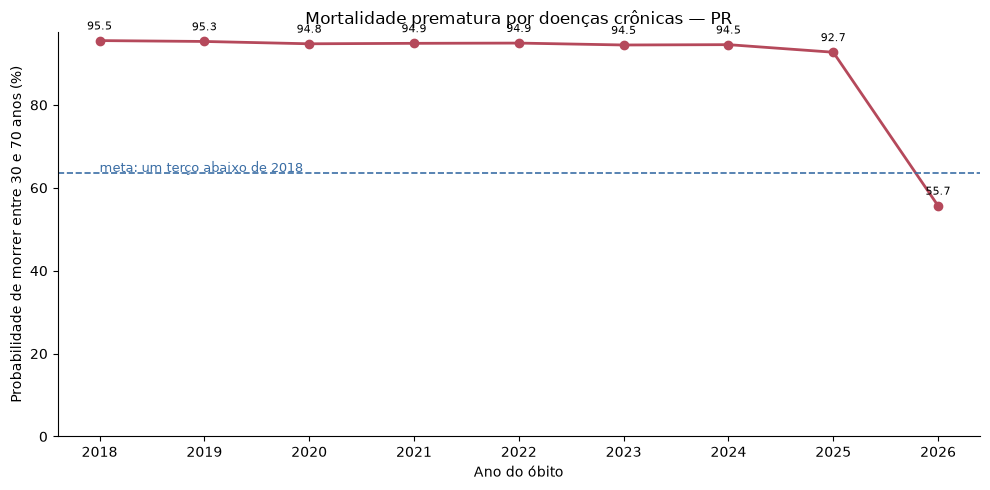

In [14]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot(historico["Ano"], historico["Probabilidade (%)"],
          marker="o", color="#b5495b", linewidth=2)

referencia = historico["Probabilidade (%)"].iloc[0]
eixo.axhline(referencia * 2 / 3, color="#3b6ea5", linestyle="--", linewidth=1.2)
eixo.text(historico["Ano"].iloc[0], referencia * 2 / 3 + 0.15,
          f"meta: um terço abaixo de {serie[0]}", color="#3b6ea5", fontsize=9)

for _, linha in historico.iterrows():
    eixo.annotate(f"{linha['Probabilidade (%)']:.1f}",
                  (linha["Ano"], linha["Probabilidade (%)"]),
                  textcoords="offset points", xytext=(0, 8),
                  ha="center", fontsize=8)

eixo.set_ylabel("Probabilidade de morrer entre 30 e 70 anos (%)")
eixo.set_xlabel("Ano do óbito")
eixo.set_title(f"Mortalidade prematura por doenças crônicas — {UF}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
eixo.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

O ano de 2020 e 2021 costumam quebrar a tendência: a covid-19 desorganizou o
atendimento às doenças crônicas e mudou a causa registrada em muitos óbitos.
Séries que cruzam a pandemia precisam dizer isso explicitamente.

## 8. Homens e mulheres

O mesmo indicador, separado por sexo. A diferença é grande e persistente.

In [15]:
por_sexo = []
for codigo, nome in [("1", "Homens"), ("2", "Mulheres")]:
    for ano in serie:
        recorte = bruto[(bruto["ano"] == ano) & (bruto["SEXO"].astype(str) == codigo)
                        & (bruto["idade"] >= 30) & (bruto["idade"] < 70)
                        & bruto["grupo_dcnt"].notna()]
        contagem = recorte["idade"].map(faixa_de).value_counts().reindex(ROTULOS_34).fillna(0)
        # a população precisa ser a do mesmo sexo
        caminho = [c for c in ibge(year=ano) if "PROJ" in os.path.basename(c)][0]
        sexo_ibge = "M" if codigo == "1" else "F"
        dados = con.execute(f"""
            SELECT CAST(substr(IDADE, 2, 2) AS INTEGER) AS idade,
                   sum(CAST(POPULACAO AS BIGINT)) AS populacao
            FROM read_parquet('{caminho.replace("\\", "/")}')
            WHERE CAST(UFCOD AS INTEGER) = {CODIGO_UF[UF]} AND SEXO = '{sexo_ibge}'
            GROUP BY 1
        """).df()
        populacao = pd.Series(
            {f"{a}-{b}": int(dados.query("idade >= @a and idade <= @b")["populacao"].sum())
             for a, b in FAIXAS_34}
        )
        por_sexo.append({"Ano": ano, "Sexo": nome,
                         "Probabilidade (%)": round(
                             probabilidade_morte_prematura(contagem, populacao), 2)})

por_sexo = pd.DataFrame(por_sexo)
comparacao = por_sexo.pivot(index="Ano", columns="Sexo", values="Probabilidade (%)")
comparacao["Razão H/M"] = (comparacao["Homens"] / comparacao["Mulheres"]).round(2)
comparacao

Sexo,Homens,Mulheres,Razão H/M
Ano,,,
2018,98.01,91.63,1.07
2019,97.87,91.36,1.07
2020,97.57,90.44,1.08
2021,97.63,90.68,1.08
2022,97.68,90.74,1.08
2023,97.39,90.14,1.08
2024,97.39,90.35,1.08
2025,96.10,88.02,1.09
2026,62.34,49.03,1.27


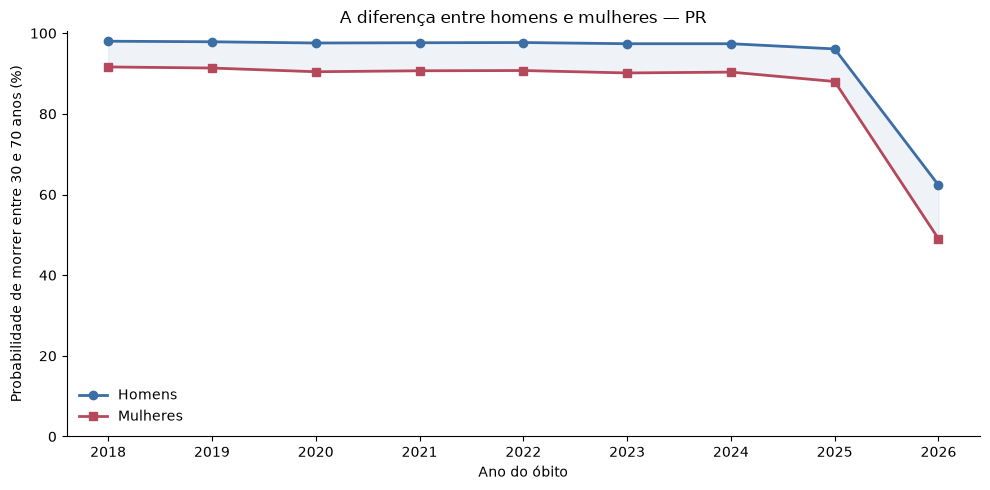

In [16]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot(comparacao.index, comparacao["Homens"], marker="o",
          color="#3b6ea5", linewidth=2, label="Homens")
eixo.plot(comparacao.index, comparacao["Mulheres"], marker="s",
          color="#b5495b", linewidth=2, label="Mulheres")
eixo.fill_between(comparacao.index, comparacao["Mulheres"], comparacao["Homens"],
                  color="#3b6ea5", alpha=0.08)

eixo.set_ylabel("Probabilidade de morrer entre 30 e 70 anos (%)")
eixo.set_xlabel("Ano do óbito")
eixo.set_title(f"A diferença entre homens e mulheres — {UF}", fontsize=12)
eixo.legend(frameon=False)
eixo.set_ylim(bottom=0)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Escolaridade e causa da morte — e uma armadilha no caminho

O SIM registra a escolaridade de quem morreu, e é tentador cruzá-la direto com
a idade do óbito. **Não faça isso.** Veja por quê:

Entre os óbitos deste estado, quem morreu com 80 anos ou mais quase nunca
estudou — não porque a falta de escola alongue a vida, mas porque essas pessoas
nasceram numa época em que poucos brasileiros iam à escola. A escolaridade
carrega a geração junto. Comparar a idade média de morte por escolaridade
produz o resultado absurdo de que os sem instrução vivem mais.

Há duas saídas, e usamos as duas:

1. **Fixar a faixa etária.** Comparando apenas mortes entre 55 e 64 anos,
   olhamos pessoas nascidas na mesma década, com o mesmo acesso à escola.
2. **Comparar composição, não taxa.** Sem um censo de escolaridade da
   população viva, não há denominador — então perguntamos *de que* morre cada
   grupo, e não *quanto* morre. Isso se chama mortalidade proporcional.

In [17]:
# Códigos do campo ESC2010 no SIM. Conferidos contra a distribuição real:
# o código 4 (superior incompleto) é raro, o que confirma a correspondência.
ESCOLARIDADE = {
    "0": "Sem escolaridade",
    "1": "Fundamental I (1ª a 4ª série)",
    "2": "Fundamental II (5ª a 8ª série)",
    "3": "Ensino médio",
    "4": "Superior incompleto",
    "5": "Superior completo",
}

obitos["escolaridade"] = obitos["ESC2010"].astype(str).str.strip().map(ESCOLARIDADE)

# A prova da armadilha: escolaridade por faixa etária do óbito.
faixas_amplas = pd.cut(obitos["idade"], [30, 40, 55, 65, 80, 200], right=False,
                       labels=["30-39", "40-54", "55-64", "65-79", "80+"])
prova = pd.crosstab(obitos["escolaridade"], faixas_amplas, normalize="columns") * 100
prova = prova.reindex([v for v in ESCOLARIDADE.values() if v in prova.index]).round(1)

print("Composição da escolaridade em cada faixa de idade ao morrer (%)")
print("(leia as colunas: a geração muda tudo)\n")
prova

Composição da escolaridade em cada faixa de idade ao morrer (%)
(leia as colunas: a geração muda tudo)


idade,30-39,40-54,55-64,65-79,80+
escolaridade,,,,,
Sem escolaridade,3.3,5.3,7.4,14.0,23.4
Fundamental I (1ª a 4ª série),13.2,28.3,41.0,50.3,53.9
Fundamental II (5ª a 8ª série),32.4,26.7,21.7,14.3,9.0
Ensino médio,36.3,28.3,20.9,13.7,8.2
Superior incompleto,3.5,2.1,1.6,1.1,0.4
Superior completo,11.3,9.3,7.5,6.7,5.1


In [18]:
def grupo_de_causa(codigo):
    "Agrupa a causa básica em blocos comparáveis entre si."
    dcnt = grupo_dcnt(codigo)
    if dcnt:
        return dcnt
    letra, numero = _numero(codigo)
    if letra is None:
        return "Demais causas"
    if letra in "AB":
        return "Infecciosas"
    if letra in "VWXY":
        return "Causas externas"
    return "Demais causas"

BANDA = (55, 64)   # uma década de nascimento: escolaridade comparável

mesma_geracao = obitos[
    obitos["idade"].between(*BANDA) & obitos["escolaridade"].notna()
].copy()
mesma_geracao["grupo_causa"] = mesma_geracao["CAUSABAS"].map(grupo_de_causa)

composicao = pd.crosstab(mesma_geracao["escolaridade"],
                         mesma_geracao["grupo_causa"], normalize="index") * 100
composicao = composicao.reindex(
    [v for v in ESCOLARIDADE.values() if v in composicao.index])
composicao["Óbitos (n)"] = mesma_geracao["escolaridade"].value_counts()
composicao = composicao.round(1)

ignorados = obitos.loc[obitos["idade"].between(*BANDA), "escolaridade"].isna().mean() * 100
print(f"Óbitos de {BANDA[0]} a {BANDA[1]} anos com escolaridade informada: "
      f"{mil(len(mesma_geracao))}")
print(f"Sem informação de escolaridade nessa faixa: {ignorados:.1f}%\n")
composicao

Óbitos de 55 a 64 anos com escolaridade informada: 11.527
Sem informação de escolaridade nessa faixa: 9.9%


grupo_causa,Causas externas,Câncer,Demais causas,Diabetes,Doenças cardiovasculares,Infecciosas,Respiratórias crônicas,Óbitos (n)
escolaridade,,,,,,,,
Sem escolaridade,7.1,19.4,28.0,6.7,27.1,4.9,6.8,856
Fundamental I (1ª a 4ª série),8.5,25.8,25.5,4.9,25.7,4.0,5.4,4721
Fundamental II (5ª a 8ª série),10.4,26.2,22.7,5.8,25.2,4.3,5.4,2496
Ensino médio,8.7,30.7,22.2,4.3,26.1,3.4,4.6,2414
Superior incompleto,6.1,35.8,25.7,4.5,21.2,5.6,1.1,179
Superior completo,7.2,39.4,22.3,3.1,21.5,4.1,2.4,861


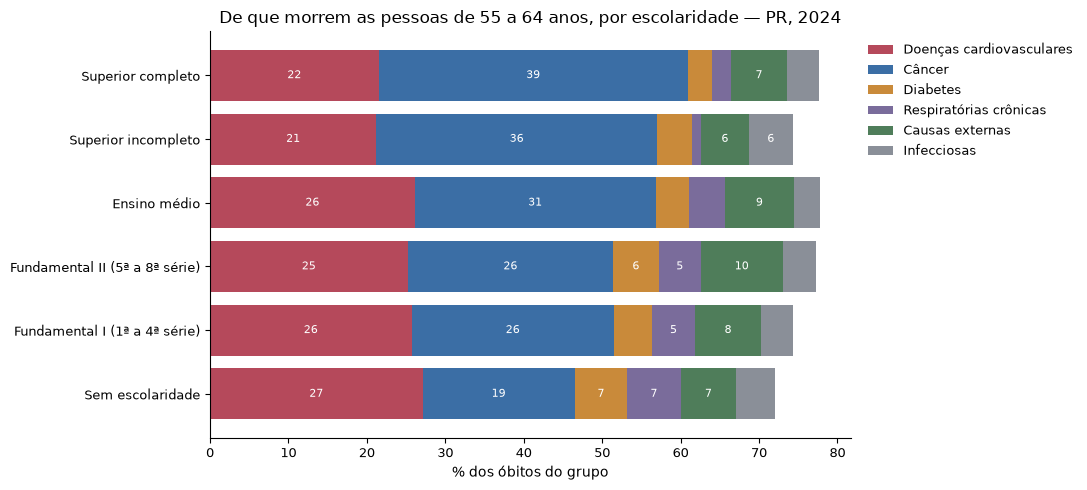

In [19]:
blocos = ["Doenças cardiovasculares", "Câncer", "Diabetes",
          "Respiratórias crônicas", "Causas externas", "Infecciosas"]
blocos = [b for b in blocos if b in composicao.columns]
cores = ["#b5495b", "#3b6ea5", "#c98a3a", "#7a6c9b", "#4f7d5a", "#8a8f98"]

figura, eixo = plt.subplots(figsize=(11, 5))
acumulado = pd.Series(0.0, index=composicao.index)

for bloco, cor in zip(blocos, cores):
    eixo.barh(composicao.index, composicao[bloco], left=acumulado,
              color=cor, label=bloco)
    for indice, (posicao, valor) in enumerate(zip(acumulado, composicao[bloco])):
        if valor >= 5:
            eixo.text(posicao + valor / 2, indice, f"{valor:.0f}",
                      ha="center", va="center", fontsize=8, color="white")
    acumulado = acumulado + composicao[bloco]

eixo.set_xlabel("% dos óbitos do grupo")
eixo.set_title(f"De que morrem as pessoas de {BANDA[0]} a {BANDA[1]} anos, "
               f"por escolaridade — {UF}, {ANO}", fontsize=12)
eixo.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)
eixo.spines[["top", "right"]].set_visible(False)
eixo.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

Dentro da mesma geração, a diferença que sobra é real. O padrão que costuma
aparecer: **causas externas e doenças infecciosas pesam mais entre quem estudou
menos; o câncer pesa mais entre quem estudou mais.** Isso não significa que os
mais escolarizados tenham mais câncer — significa que eles chegam a idades em
que o câncer é o que resta, enquanto os outros morrem antes, de outras coisas.

Para transformar isso em taxa — e poder dizer "o risco é X vezes maior" —
seria preciso a população viva por escolaridade, que o censo fornece a cada dez
anos. Com dados anuais, a mortalidade proporcional é o que se pode afirmar com
honestidade.

## 10. Conferindo com a realidade

Quatro checagens que qualquer leitor pode repetir:

In [20]:
circulatorio = por_capitulo.loc["IX. Aparelho circulatório", "% do total"]
neoplasias = por_capitulo.loc["II. Neoplasias (tumores)", "% do total"]

print("Verificações de sanidade\n")
print(f"0. Óbitos no ano                          {mil(len(obitos))}")
print(f"1. Circulatório é a principal causa?      {circulatorio}% "
      f"({'sim' if circulatorio > 20 else 'ATENÇÃO'})")
print(f"2. Neoplasias vêm em seguida?             {neoplasias}% "
      f"({'sim' if neoplasias > 15 else 'ATENÇÃO'})")
print(f"3. Causas mal definidas abaixo de 10%?    {mal_definidas}% "
      f"({'sim' if mal_definidas < 10 else 'ATENÇÃO'})")
print(f"4. Indicador 3.4 na faixa esperada?       {resultado:.1f}% "
      f"({'sim' if 8 < resultado < 25 else 'ATENÇÃO'})")
print()
print("Referências: no Brasil, o aparelho circulatório responde por cerca de")
print("27% dos óbitos e as neoplasias por cerca de 19%. A probabilidade de morte")
print("prematura por DCNT ficou entre 13% e 17% nos últimos anos.")

Verificações de sanidade
0. Óbitos no ano                          89.122
1. Circulatório é a principal causa?      25.4% (sim)
2. Neoplasias vêm em seguida?             19.3% (sim)
3. Causas mal definidas abaixo de 10%?    1.8% (sim)
4. Indicador 3.4 na faixa esperada?       14.4% (sim)
Referências: no Brasil, o aparelho circulatório responde por cerca de
27% dos óbitos e as neoplasias por cerca de 19%. A probabilidade de morte
prematura por DCNT ficou entre 13% e 17% nos últimos anos.


## 11. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "BA"` |
| Série mais longa | `ANOS_SERIE = 15` |
| Só um município | filtre `obitos["CODMUNRES"] == "4106902"` antes das contas |
| Outro grupo de causas | edite `GRUPOS_DCNT` com as faixas da CID que interessam |
| Mortalidade por suicídio | use `capitulo_cid10` e filtre `X60` a `X84` |
| Comparar estados | rode o notebook em laço sobre `UFS.values()`, mas padronize por idade antes de comparar (veja o notebook do IBGE) |

### As funções que valem levar

`capitulo_cid10(codigo)` — serve para SIM, SIH e SINAN.
`idade_em_anos(codigo)` — decodifica a idade do SIM, que engana quem não sabe.
`probabilidade_morte_prematura(obitos, populacao)` — o cálculo da meta 3.4.
`grupo_de_causa(codigo)` — blocos de causa comparáveis entre si.

### E os dois cuidados que valem mais que as funções

**Não compare escolaridade sem fixar a idade** — a escolaridade carrega a
geração junto, e o resultado sai invertido.
**Não compare taxas brutas entre lugares** — padronize por idade primeiro.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SIM/DATASUS e IBGE, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*